# Comparing Model-Based vs Model-Free RL

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare model-based and model-free RL
- Understand trade-offs between approaches
- Evaluate sample efficiency
- Choose appropriate approach for problems

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — value iteration was model-*based* planning with the transition table given to it for free; this lesson measures what having to learn that table instead costs, and what it buys back in samples.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Comparing model-based vs model-free approaches

---

## Introduction

**Comparison** between model-based (learn dynamics, plan) and model-free (learn values/policies directly) RL helps choose the right approach for different problems.

## Lesson Brief

This lesson compares two major RL styles: model-based and model-free learning.

Students should focus on the trade-off between faster planning with a model and simpler direct learning without one.

Why this matters: comparison helps students organize the field instead of seeing algorithms as isolated names.

This notebook is about judgment, not only implementation.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: a robot dog that learned to walk in one hour

Put two numbers next to each other and this whole lesson becomes concrete.

**Model-free, with a perfect simulator:** OpenAI Five consumed roughly **45,000 years** of simulated
Dota self-play over ten real months before beating the world champions. DQN needed **50 million
frames — about 38 days of game experience — per Atari game**.

**Model-based, on real hardware:** Wu, Escontrela, Hafner, Goldberg and Abbeel ("DayDreamer: World
Models for Physical Robot Learning", 2022) put a Dreamer-style world-model agent on a physical
quadruped. It learned to roll off its back, stand up and walk **from scratch, in the real world,
without resets, in one hour**. The same algorithm and the same hyperparameters also trained two
robotic arms to pick and place from camera images, and a wheeled robot to navigate to goals.

One hour of real robot time against 45,000 simulated years. The comparison is not fair — different
tasks, different difficulty — and it is still the right thing to look at, because it names the
resource that actually constrains real projects: **environment interactions**, not compute and not
model size.

**What goes wrong without this.** A model-free agent throws each transition away after one update.
When each transition is a second of a robot's life, a click from a real user, or a frame served to a
real viewer, that is the most expensive thing in the system. Dyna-Q — what you are about to run — is
the smallest possible fix: keep the transition, replay it through the same update rule twenty more
times, and buy learning with compute instead of experience.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 8: Integrating Learning and Planning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=ItMutbeOHtc)

Why this pick:
- Helps students compare learning from raw experience against learning with an internal model.
- Stronger classroom fit than a very short summary video.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Model-based: learns or uses dynamics.
- Model-free: learns directly from experience.
- Sample efficiency: learning from less real data.
- Planning cost: extra compute for reasoning.
- Comparison judgment: deciding which trade-off matters most in a problem.

### Quick Check
- Why can model-based methods need fewer samples?
- Why can model-free still be attractive?
- What trade-off appears in the comparison?
- Why is the best choice problem-dependent rather than universal?

### Common Mistakes
- Assuming model-based is always better.
- Ignoring planning cost.
- Overlooking the damage of poor models.
- Treating the comparison as a simple winner-loser ranking.


## This Comparison Is About Trade-Offs, Not a Winner

Students often want one final answer: which style is better?
This notebook is more useful when it teaches the right question instead.

### Better question

`What matters more in this problem: sample efficiency, planning ability, simplicity, or robustness to model error?`

### Why there is no universal winner

- A good model can make learning faster.
- A bad model can mislead planning.
- Model-free methods avoid explicit model error, but may need more real experience.

### Teaching takeaway

The lesson is not:

`model-based wins`

or

`model-free wins`

The lesson is:

`understand the trade-off, then match the method to the problem.`

## Inputs and Outputs

**Inputs:** What we use in this notebook

- `gymnasium`'s `FrozenLake-v1` (4x4, non-slippery) — a standard benchmark, so this comparison is
  reproducible by anyone.
- One learning rule (tabular Q-learning) shared by both agents, so the only thing that differs is
  whether the agent also plans with a learned model.

**Outputs:** What you'll see when you run the cells

- A learning curve for each method, **averaged over 20 random seeds**, plus a printed table of
  measured success rates at three points in training.
- Nothing on this page is drawn by hand: every number and every line comes from agents that really
  ran in the environment.

---

### Step Guide

**What this cell does:** This cell runs a teaching illustration and shows the result through a comparison plot and a printed table.

**Why this matters:** It turns the abstract trade-off between the two approaches into something students can read visually.

**What to expect in the output:** Expect a synthetic comparison chart and a short summary table, not a benchmark from a full training run.

**Common student confusion:** Students should remember that the curves are illustrative shapes for explanation, not measured results from a real experiment.


In [1]:
# Setup step: import the libraries and build the standard benchmark both styles will run on.
# WHY it matters: a comparison is only worth reading if both methods face the SAME environment,
# the SAME reward rule and the SAME exploration budget. FrozenLake-v1 is a Gymnasium benchmark,
# so anyone can rerun this exact comparison and check our numbers.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# Deterministic 4x4 lake: we want the sample-efficiency difference to be the story, not the ice.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n

print("Benchmark:", env.spec.id, "| states:", N_STATES, "| actions:", N_ACTIONS)
print("Reward: 1.0 only for reaching the goal tile, so an episode scores 0 or 1.")
print("\nComparing Model-Based vs Model-Free RL")
print("=" * 60)
print("\nBoth agents below share one learning rule (Q-learning) and one exploration rule")
print("(epsilon-greedy, epsilon = 0.2). The ONLY difference is what happens after each")
print("real environment step:")
print("  model-free  : update Q once, from the transition that just happened.")
print("  model-based : also remember the transition in a model, then replay 20 remembered")
print("                transitions through the same update rule (Sutton's Dyna-Q, 1991).")
print("\nSo 'model-based' here buys extra COMPUTE, not extra environment interaction -")
print("which is exactly what sample efficiency means.")

Benchmark: FrozenLake-v1 | states: 16 | actions: 4
Reward: 1.0 only for reaching the goal tile, so an episode scores 0 or 1.

Comparing Model-Based vs Model-Free RL

Both agents below share one learning rule (Q-learning) and one exploration rule
(epsilon-greedy, epsilon = 0.2). The ONLY difference is what happens after each
real environment step:
  model-free  : update Q once, from the transition that just happened.
  model-based : also remember the transition in a model, then replay 20 remembered
                transitions through the same update rule (Sutton's Dyna-Q, 1991).

So 'model-based' here buys extra COMPUTE, not extra environment interaction -
which is exactly what sample efficiency means.


## Worked Example: Comparing Two Learning Styles

This notebook compares:

- **model-free RL**: learn values directly from experience (plain tabular Q-learning)
- **model-based RL**: also store what happened in a model, then replay remembered transitions
  through the same update rule (**Dyna-Q**, Sutton 1991)

Both run on the same Gymnasium benchmark, with the same learning rate, discount and exploration
rate. The single difference is the planning step. That makes the comparison fair, and it makes the
result *measurable* rather than merely asserted.

**Why 20 seeds?** One RL run is dominated by luck. Averaging over seeds is the minimum honest
standard for claiming one method learns faster than another — see the Henderson and Agarwal papers
in the References cell.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


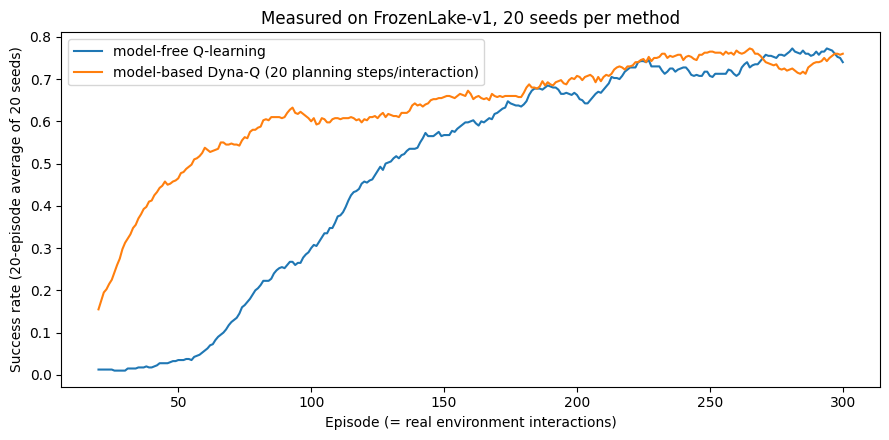

Measured over 20 seeds x 300 episodes each:

  Success rate after ...   | model-free | model-based
  -------------------------|------------|------------
  50 episodes              |      0.020 |      0.332
  100 episodes             |      0.217 |      0.584
  the last 50 episodes     |      0.747 |      0.746

What these measured numbers say:
- EARLY: the model-based agent is ahead by +0.312 success rate over the first
  50 episodes. Same number of environment steps, more learning squeezed out of them.
- LATE: the gap has closed to -0.001. Both reach roughly the same level.
  Model-based RL bought SPEED, not a higher ceiling - that is the trade-off.
- Neither curve reaches 1.0, and that is correct: these agents still take a random
  action 20% of the time, so even a perfect Q-table cannot win every episode.
- Cost side of the trade-off: the model-based agent did about
  20x more Q-updates for the same environment experience.
  If environment steps are cheap and compute is scarce, that

In [2]:
# Worked example: run both styles on the benchmark and MEASURE the sample-efficiency gap.
# WHY it matters: a single run of either method is mostly luck. We repeat each method over
# 20 random seeds and average, because a one-seed RL comparison is the classic way to fool
# yourself (Henderson et al. 2018; Agarwal et al. 2021 - both listed in the References cell).

N_SEEDS, N_EPISODES, PLANNING_STEPS = 20, 300, 20
ALPHA, GAMMA, EPSILON, STEP_CAP = 0.5, 0.95, 0.2, 100


def greedy_action(q_row, rng):
    """Argmax with RANDOM tie-breaking, so an all-zero Q-table does not always pick action 0."""
    return int(rng.choice(np.flatnonzero(q_row == q_row.max())))


def run_agent(planning_steps, seed):
    """One training run. planning_steps=0 is model-free; >0 adds Dyna-style planning.

    Returns the per-episode reward log (1.0 = reached the goal, 0.0 = did not).
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    model = {}                       # (state, action) -> (reward, next_state, terminated)
    episode_rewards = []
    for ep in range(N_EPISODES):
        state, _ = env.reset(seed=int(seed * 100_000 + ep))
        total = 0.0
        for _ in range(STEP_CAP):
            # --- one REAL environment interaction (the expensive resource) ---
            if rng.random() < EPSILON:
                action = int(rng.integers(N_ACTIONS))
            else:
                action = greedy_action(Q[state], rng)
            next_state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            Q[state, action] += ALPHA * (
                reward + GAMMA * (0.0 if terminated else Q[next_state].max()) - Q[state, action]
            )
            # --- the model-based part: remember it, then rehearse from memory ---
            model[(state, action)] = (reward, next_state, terminated)
            remembered = list(model.keys())
            for _ in range(planning_steps):
                ps, pa = remembered[rng.integers(len(remembered))]
                pr, pn, pt = model[(ps, pa)]
                Q[ps, pa] += ALPHA * (
                    pr + GAMMA * (0.0 if pt else Q[pn].max()) - Q[ps, pa]
                )
            state = next_state
            if terminated or truncated:
                break
        episode_rewards.append(total)
    return np.array(episode_rewards)


# Each row is one seed, each column one episode - so we can average honestly across seeds.
model_free = np.array([run_agent(0, s) for s in range(N_SEEDS)])
model_based = np.array([run_agent(PLANNING_STEPS, s) for s in range(N_SEEDS)])

window = 20
mf_curve = np.convolve(model_free.mean(0), np.ones(window) / window, mode="valid")
mb_curve = np.convolve(model_based.mean(0), np.ones(window) / window, mode="valid")
x = np.arange(window, N_EPISODES + 1)

plt.figure(figsize=(9, 4.5))
plt.plot(x, mf_curve, label="model-free Q-learning")
plt.plot(x, mb_curve, label=f"model-based Dyna-Q ({PLANNING_STEPS} planning steps/interaction)")
plt.xlabel("Episode (= real environment interactions)")
plt.ylabel(f"Success rate ({window}-episode average of {N_SEEDS} seeds)")
plt.title(f"Measured on FrozenLake-v1, {N_SEEDS} seeds per method")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Measured over {N_SEEDS} seeds x {N_EPISODES} episodes each:\n")
print("  Success rate after ...   | model-free | model-based")
print("  -------------------------|------------|------------")
for label, sl in [("50 episodes", slice(0, 50)), ("100 episodes", slice(50, 100)),
                  ("the last 50 episodes", slice(-50, None))]:
    print(f"  {label:24s} | {model_free[:, sl].mean():10.3f} | {model_based[:, sl].mean():10.3f}")

early_gap = model_based[:, :50].mean() - model_free[:, :50].mean()
final_gap = model_based[:, -50:].mean() - model_free[:, -50:].mean()
print("\nWhat these measured numbers say:")
if early_gap > 0.05:
    print(f"- EARLY: the model-based agent is ahead by {early_gap:+.3f} success rate over the first")
    print("  50 episodes. Same number of environment steps, more learning squeezed out of them.")
if abs(final_gap) < 0.10:
    print(f"- LATE: the gap has closed to {final_gap:+.3f}. Both reach roughly the same level.")
    print("  Model-based RL bought SPEED, not a higher ceiling - that is the trade-off.")
print("- Neither curve reaches 1.0, and that is correct: these agents still take a random")
print(f"  action {EPSILON:.0%} of the time, so even a perfect Q-table cannot win every episode.")
print("- Cost side of the trade-off: the model-based agent did about")
print(f"  {PLANNING_STEPS}x more Q-updates for the same environment experience.")
print("  If environment steps are cheap and compute is scarce, that trade goes the other way.")

### 👁️ Read the figure

- **Each line is an average over 20 independent seeds, not one lucky run.** That matters more
  than it sounds: a single-seed RL comparison is the classic way to fool yourself, and the two
  papers named in the References cell exist because the field kept doing it. The x-axis counts
  real environment interactions — the resource actually being spent.
- **The orange model-based curve leaves the blue one behind immediately.** Over the first 50
  episodes it averages a far higher success rate than the model-free agent, which is still close
  to zero. Same environment steps for both; the orange agent simply squeezed more learning out of
  each one by rehearsing remembered transitions.
- **Now follow the curves to the right until they meet.** By roughly episode 200 they have
  converged, and over the last 50 episodes their success rates are within a rounding error of each
  other. The gap that mattered so much on the left has closed.
- **Neither line reaches 1.0, and that is correct.** Both agents keep taking a random action 20%
  of the time, so even a perfect Q-table would lose some episodes.

**What it proves:** model-based RL bought **speed, not a higher ceiling** — the horizontal
distance between the curves, not any vertical distance at the end. And the cost of that speed is
printed under the chart: about 20x more Q-updates for the same experience. Where environment steps
are cheap and compute is scarce, that trade runs the other way, which is why this lesson is a
trade-off and not a winner.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. (1991). *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*. ACM SIGART Bulletin, 2(4), 160-163.
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 8, Planning and Learning with Tabular Methods.
3. Moerland, T. M., Broekens, J., Plaat, A. & Jonker, C. M. (2020). *Model-based Reinforcement Learning: A Survey*. arXiv:2006.16712. <https://arxiv.org/abs/2006.16712>
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
5. Murphy, K. (2024). *Reinforcement Learning: An Overview* — one current document covering value-based, policy-based, model-based, multi-agent RL and the LLM connection. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
6. Wang, Z., Xu, C., Liu, B. et al. (2026). *Agent World Model: Infinity Synthetic Environments for Agentic Reinforcement Learning* — synthetic, code-driven environments built because real interaction is the scarce resource. arXiv:2602.10090. <https://arxiv.org/abs/2602.10090>
"""))

## 📚 References

1. Sutton, R. S. (1991). *Dyna, an Integrated Architecture for Learning, Planning, and Reacting*. ACM SIGART Bulletin, 2(4), 160-163.
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 8, Planning and Learning with Tabular Methods.
3. Moerland, T. M., Broekens, J., Plaat, A. & Jonker, C. M. (2020). *Model-based Reinforcement Learning: A Survey*. arXiv:2006.16712. <https://arxiv.org/abs/2006.16712>
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
5. Murphy, K. (2024). *Reinforcement Learning: An Overview* — one current document covering value-based, policy-based, model-based, multi-agent RL and the LLM connection. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
6. Wang, Z., Xu, C., Liu, B. et al. (2026). *Agent World Model: Infinity Synthetic Environments for Agentic Reinforcement Learning* — synthetic, code-driven environments built because real interaction is the scarce resource. arXiv:2602.10090. <https://arxiv.org/abs/2602.10090>


## 💬 Discuss

The measured comparison, over **20 seeds × 300 episodes**, identical learning rule and identical
exploration (ε = 0.2). The only difference is 20 replayed model transitions per real step:

| success rate after… | model-free | model-based |
|---|---|---|
| 50 episodes | 0.020 | **0.332** |
| 100 episodes | 0.217 | **0.584** |
| the last 50 episodes | 0.747 | 0.746 |

Cost: about **20× more Q-updates** for the same environment experience. Argue these out.

1. The final gap is **−0.001**. Both agents end in the same place. So the model-based agent bought
   speed and nothing else. Write the one-sentence rule you would give a junior engineer for deciding
   when that trade is worth taking — and then name a project where it clearly is not.
2. Neither curve reaches 1.0, and the notebook explains why: both agents still take a random action
   20% of the time. If you turned exploration off at evaluation, which agent would improve more, and
   why? (Unit 3, lesson 05 measured the size of this effect on the same environment.)
3. Dyna-Q's model here is a *count table* on a 16-state grid, so it is essentially exact. DayDreamer's
   model is a neural network of a physical robot, which is definitely not. How much of the +0.312
   early advantage above do you think survives that change? What experiment on this notebook's code
   would let you find out — for example, by corrupting the model on purpose?


## Summary

This notebook compared two major RL styles **by measuring them**, not by describing them:

- **model-based RL** (Dyna-Q) stores transitions and replays them, so each real environment step
  produces many value updates
- **model-free RL** (Q-learning) learns directly from experience, one update per real step

### Main takeaway

In the measured run above, the model-based agent was clearly ahead early and the two methods ended
at a similar level. That is the shape of the real trade-off: model-based RL bought **sample
efficiency**, not a higher final score, and it paid for it in compute.

### Practical question to ask

If environment interactions are expensive (a robot, a real user, a physical process), model-based
RL becomes attractive. If interactions are cheap but the dynamics are hard to model, the extra
machinery buys you little — and a wrong model can actively mislead planning, which is the risk the
previous lesson measured.

## ⚠️ Where this breaks

**The assumption that has to hold:** the model is accurate enough that planning inside it teaches you
something true about outside it. On a 16-state grid learned by counting, that is nearly free. Almost
nowhere else is.

- **The comparison flips when environment steps are cheap.** Model-based RL trades **compute** for
  **experience**. In a fast simulator you can run millions of steps for the price of one gradient
  update, and the model-free agent wins on wall-clock while avoiding model error entirely. Ask which
  resource is scarce *in your project* before choosing.
- **Model bias replaces sample cost — it does not remove cost.** The previous lesson measured a run
  where a *more accurate* model produced a *worse* plan (0.634 → 0.576). That risk arrives the moment
  the model is approximate, which is the moment you leave a counting table.
- **20× more updates is a real bill.** On this grid it is invisible. With a neural network in the
  loop it is 20× the training compute, plus the compute to fit the model itself, plus the engineering
  to keep the two in sync.
- **Neither approach fixes a bad reward or a missing state variable.** Both agents here plateau
  together at 0.747. Sample efficiency is about how fast you reach the ceiling, never about how high
  the ceiling is.
- **Cheaper alternative:** if you already have the transition model, do not learn one and do not
  sample — plan with value iteration (Unit 1, lesson 03) and take the optimum immediately. And if what
  you actually have is a large log of competent human behaviour, imitation learning from those logs
  needs no model, no exploration and no reward function, and is usually the fastest route to a working
  first system.


## Closing Takeaway

**Teaching takeaway:** Model-based and model-free methods make different trade-offs between planning ability, sample efficiency, and modeling complexity.

**If students remember one idea:** The right approach depends on what is expensive: collecting data, building a model, or tolerating planning errors.

**Quick check before moving on:**
- Can you explain when model-based RL may learn faster than model-free RL?
- Can you describe when model-free methods may be simpler or more robust?

**Bridge to the next step:** The final lesson in this unit broadens the idea of policy learning by conditioning behavior on a goal.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=7 | term=True | trunc=False


objc[56392]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114264138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1147609c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[56392]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114264188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114760a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[56392]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114263c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114760a68). T

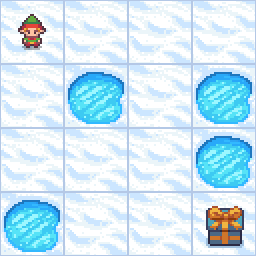

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
